#Analisis Data Eksploratif Jenius App

##Instalasi dan Import Library

In [1]:
!pip install matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Konfigurasi tampilan
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

available_styles = matplotlib.style.available
if 'seaborn-v0_8' in available_styles:
    plt.style.use('seaborn-v0_8')
elif 'seaborn' in available_styles:
    plt.style.use('seaborn')
else:
    plt.style.use('ggplot')

pd.set_option('display.max_colwidth', 200)
print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


##Load Dataset

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# Load dataset ulasan Jenius
df_jenius = pd.read_csv('/content/drive/My Drive/PBA/rawdata_jenius_id.csv', low_memory=False)
df_jenius.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c4fff659-dc8d-4449-92bd-c31e47cce376,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"payah udah cape"" isi data , login suruh isi data lgi . payah dah.",1,0,4.66.1,2026-03-23 09:31:49,"Mohon maaf atas ketidaknyamanan yang kamu alami ya Irfan. Agar dapat dibantu pengecekan lebih lanjut, mohon kesediaan kamu menghubungi SMBCI Care 1500365 ya.",2026-03-23 09:32:47,4.66.1
1,cbfc7f4a-d5f6-48ef-a6f6-2a30ea8e159d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,mohon bantu saya tidak pernah mengajukan pinjaman di aplikasi ini kenapa saya laporan di bi checking cacat Krn aplikasi ini,1,0,4.66.1,2026-03-23 07:25:07,"Hi Sarwedi Silalahi. Mohon maaf atas ketidaknyamanan yang kamu alami. Untuk dibantu pengecekan, mohon kesediaannya kamu dapat menghubungi SMBCI Care melalui telepon di 1500365 atau live chat di da...",2026-03-23 07:32:36,4.66.1
2,163b3f92-772b-41d5-9c89-2d083ed3a355,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,mobile banking paling berat dan lambat yang pernah saya pakai. Tolong diupgrade.,1,0,4.66.1,2026-03-22 23:24:37,"Hi Kusnadi. Mohon maaf atas ketidaknyamanannya. Pastikan koneksi internet dalam keadaan stabil/menggunakan jaringan lain, aplikasi Jenius versi terbaru dan melakukan clear cache. Hal ini menjadi p...",2026-03-22 23:31:12,4.66.1
3,b0eb2070-29d3-4f1d-b525-b2ecc70d0bda,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"tolong perbaiki sistemnya ya, kita sudah berusaha untuk selalu tepat waktu namun sistem selalu membaca terlambat, dan akhirnya terbaca kredibilitas kita kurang, yang mengakibatnya penurunan limit ...",1,0,NaN,2026-03-22 13:33:56,"Hai Andhy Hutomo. Terima kasih atas ulasan yang kamu berikan kepada Jenius. Mohon maaf atas ketidaknyamanan yang kamu alami, informasi yang kamu sampaikan menjadi perhatian dan masukan bagi kami u...",2026-03-22 13:35:34,NaN
4,e265485e-090f-4b1c-9a0b-6df7bdadebfd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"saya ingin unlink device, tapi sangat sulit. sudah menghubungi lewat email, sudah telpon tapi memakan pulsa, tapi saya sudah beli paket telpon, tidak bisa ditelpon jika menggunakan angka 021.",1,0,4.66.1,2026-03-22 11:17:12,Hi Kak. Mohon maaf atas ketidaknyamanan yang dialami. Jika melalui layanan e-mail Jenius-Help@smbci.com untuk pengajuan unlink device kamu dapat sampaikan ingin dibantu Unlink Device dan informasi...,2026-03-22 11:19:39,4.66.1


In [23]:
# Ringkasan informasi dataset
df_jenius.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101151 entries, 0 to 101150
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              101151 non-null  object
 1   userName              101151 non-null  object
 2   userImage             101151 non-null  object
 3   content               101147 non-null  object
 4   score                 101151 non-null  int64 
 5   thumbsUpCount         101151 non-null  int64 
 6   reviewCreatedVersion  69106 non-null   object
 7   at                    101151 non-null  object
 8   replyContent          29697 non-null   object
 9   repliedAt             29697 non-null   object
 10  appVersion            69106 non-null   object
dtypes: int64(2), object(9)
memory usage: 8.5+ MB


##Transformasi Format Data Waktu

Kolom `at` yang semula bertipe string dikonversi ke format `datetime` agar analisis berbasis waktu dapat dilakukan secara kronologis. Validasi tipe data dilakukan setelah proses konversi untuk memastikan struktur kolom telah sesuai.

In [24]:
df_jenius['at'] = pd.to_datetime(df_jenius['at'])
df_jenius.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101151 entries, 0 to 101150
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              101151 non-null  object        
 1   userName              101151 non-null  object        
 2   userImage             101151 non-null  object        
 3   content               101147 non-null  object        
 4   score                 101151 non-null  int64         
 5   thumbsUpCount         101151 non-null  int64         
 6   reviewCreatedVersion  69106 non-null   object        
 7   at                    101151 non-null  datetime64[ns]
 8   replyContent          29697 non-null   object        
 9   repliedAt             29697 non-null   object        
 10  appVersion            69106 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 8.5+ MB


##Distribusi Skor Ulasan

Perhitungan proporsi jumlah ulasan pada setiap tingkatan rating (1–5 bintang) dilakukan untuk mendeteksi potensi ketidakseimbangan data (*data imbalance*) yang dapat memengaruhi hasil pemodelan sentimen.

In [25]:
df_jenius['score'].value_counts()

,count
score,
5,68031
1,20194
3,4971
4,4092
2,3863


##Distribusi Skor Ulasan

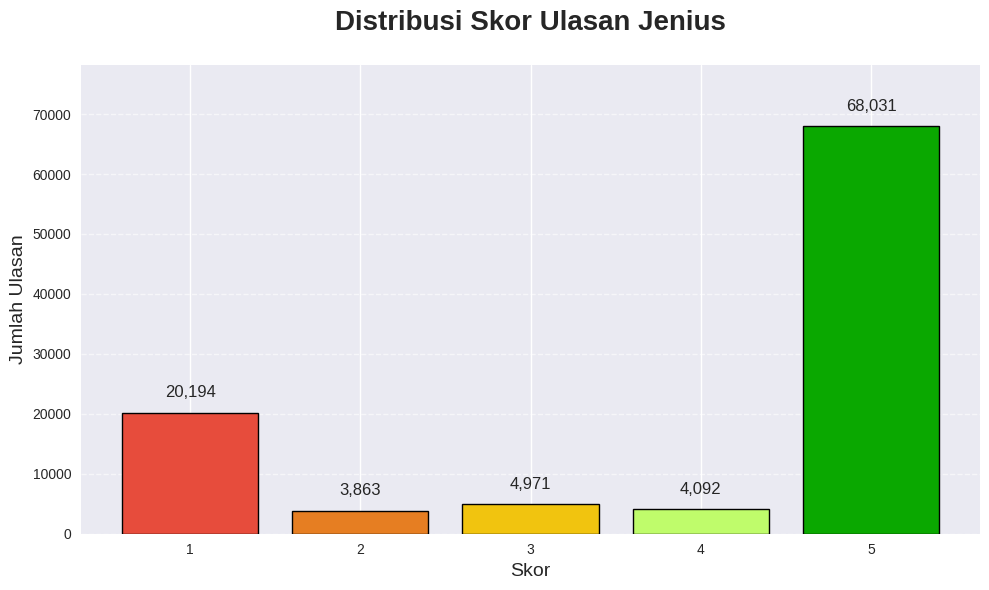

In [26]:
df_count = df_jenius['score'].value_counts().sort_index()

score_colors = {
    1: '#e74c3c',
    2: '#e67e22',
    3: '#f1c40f',
    4: '#bffc6b',
    5: '#0aa800',
}
colors = [score_colors[s] for s in df_count.index]

plt.figure(figsize=(10, 6))
bars = plt.bar(df_count.index, df_count.values, color=colors, edgecolor='black', linewidth=1)

plt.title('Distribusi Skor Ulasan Jenius', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Skor', fontsize=14)
plt.ylabel('Jumlah Ulasan', fontsize=14)

max_val = max(df_count.values)
plt.ylim(top=max_val * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max_val * 0.03,
        f"{height:,}",
        ha='center', va='bottom', fontsize=12
    )

plt.tight_layout()
plt.show()

##Distribusi

/tmp/ipykernel_786/2657988967.py:37: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


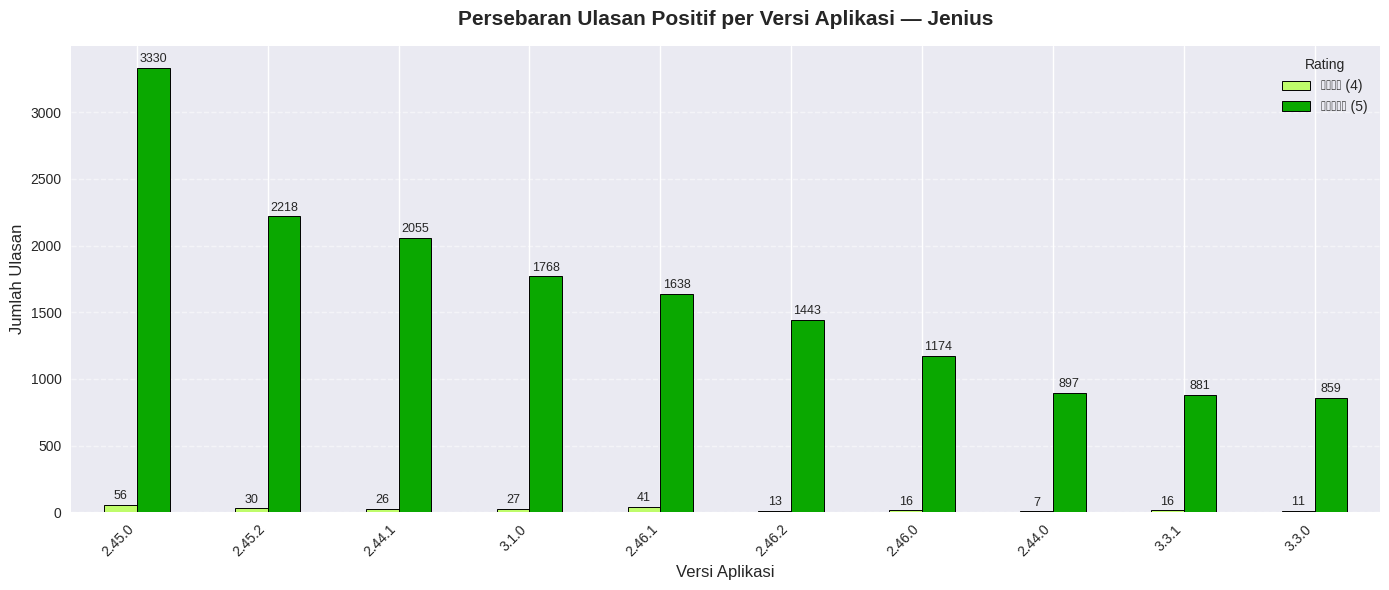

=== RINGKASAN ULASAN POSITIF PER VERSI (TOP 10) ===


,Rating 4,Rating 5,Total Positif
reviewCreatedVersion,,,
2.45.0,56,3330,3386
2.45.2,30,2218,2248
2.44.1,26,2055,2081
3.1.0,27,1768,1795
2.46.1,41,1638,1679
2.46.2,13,1443,1456
2.46.0,16,1174,1190
2.44.0,7,897,904
3.3.1,16,881,897


In [28]:
# Persebaran Respon Positif per Versi Aplikasi berdasarkan Rating

# Filter hanya rating positif (score 4 dan 5)
df_positive = df_jenius[df_jenius['score'] >= 4].copy()

# Hapus baris tanpa info versi
df_positive = df_positive[df_positive['reviewCreatedVersion'].notna()]

# Hitung jumlah ulasan positif per versi dan per skor
df_pivot = df_positive.groupby(['reviewCreatedVersion', 'score']).size().unstack(fill_value=0)

# Ambil top 10 versi dengan total ulasan positif terbanyak
df_pivot['total'] = df_pivot.sum(axis=1)
df_pivot = df_pivot.nlargest(10, 'total').drop(columns='total')

# Visualisasi
ax = df_pivot.plot(
    kind='bar',
    figsize=(14, 6),
    color={4: '#bffc6b', 5: '#0aa800'},
    edgecolor='black',
    linewidth=0.7
)

plt.title('Persebaran Ulasan Positif per Versi Aplikasi — Jenius',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Versi Aplikasi', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rating', labels=['⭐⭐⭐⭐ (4)', '⭐⭐⭐⭐⭐ (5)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tambah label nilai di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=2)

plt.tight_layout()
plt.show()

# Tampilkan tabel ringkasan
print('=== RINGKASAN ULASAN POSITIF PER VERSI (TOP 10) ===')
df_pivot['Total Positif'] = df_pivot.sum(axis=1)
df_pivot.columns = ['Rating 4', 'Rating 5', 'Total Positif']
display(df_pivot.sort_values('Total Positif', ascending=False))

##Tren Frekuensi Ulasan Tahunan

Analisis volume ulasan yang masuk per tahun dilakukan untuk memetakan dinamika pertumbuhan pengguna aplikasi Jenius dari waktu ke waktu. Observasi ini penting untuk memastikan dataset mencakup rentang waktu yang representatif.

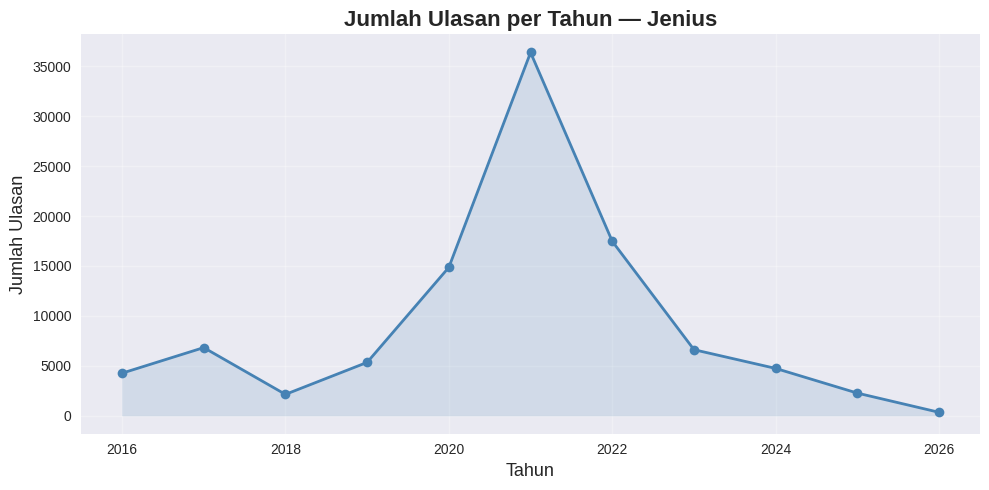

In [9]:
df_yearly = df_jenius.groupby(df_jenius['at'].dt.year).size()

plt.figure(figsize=(10, 5))
plt.plot(df_yearly.index, df_yearly.values, marker='o', linewidth=2, color='steelblue')
plt.fill_between(df_yearly.index, df_yearly.values, alpha=0.15, color='steelblue')

plt.title('Jumlah Ulasan per Tahun — Jenius', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=13)
plt.ylabel('Jumlah Ulasan', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##Tren Rata-rata Skor Tahunan

Evaluasi fluktuasi tingkat kepuasan pengguna dilakukan dengan menghitung rata-rata skor ulasan per tahun untuk mengamati apakah kualitas pengalaman pengguna cenderung meningkat, stabil, atau menurun secara kronologis.

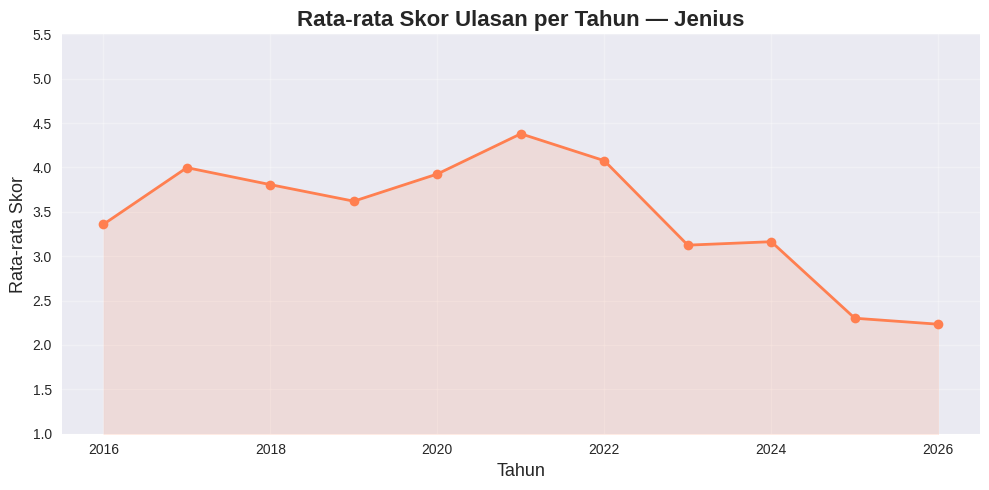

In [10]:
df_yearly_score = df_jenius.groupby(df_jenius['at'].dt.year)['score'].mean()

plt.figure(figsize=(10, 5))
plt.plot(df_yearly_score.index, df_yearly_score.values, marker='o', linewidth=2, color='coral')
plt.fill_between(df_yearly_score.index, df_yearly_score.values, alpha=0.15, color='coral')

plt.title('Rata-rata Skor Ulasan per Tahun — Jenius', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=13)
plt.ylabel('Rata-rata Skor', fontsize=13)
plt.ylim(1, 5.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##Distribusi Panjang Ulasan

Sebaran jumlah karakter pada setiap ulasan dianalisis melalui histogram untuk memahami kecenderungan pengguna dalam menyampaikan umpan balik, serta mendeteksi keberadaan pencilan (*outliers*) pada dataset.

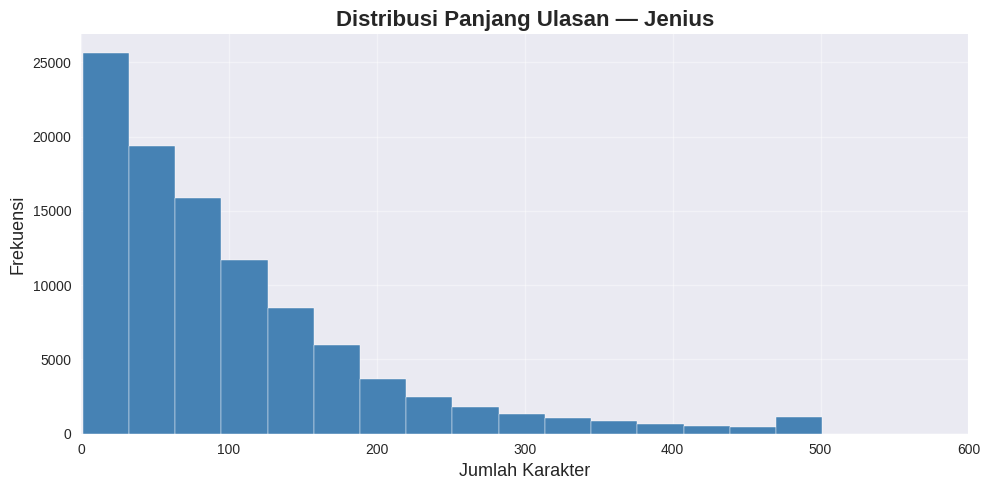

In [11]:
df_jenius['text_length'] = df_jenius['content'].astype(str).apply(len)

plt.figure(figsize=(10, 5))
plt.hist(df_jenius['text_length'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribusi Panjang Ulasan — Jenius', fontsize=16, fontweight='bold')
plt.xlabel('Jumlah Karakter', fontsize=13)
plt.ylabel('Frekuensi', fontsize=13)
plt.xlim(0, 600)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

##Statistik Panjang Ulasan per Skor

Hubungan antara tingkat kepuasan (skor rating) dan panjang teks ulasan ditelaah melalui perhitungan statistik deskriptif. Analisis ini memberikan gambaran mengenai pola perilaku pengguna dalam memberikan deskripsi ulasan pada setiap kategori skor.

In [12]:
df_jenius['text_length'] = df_jenius['content'].astype(str).apply(len)
df_jenius.groupby('score')['text_length'].agg(['count', 'mean', 'median', 'max'])

,count,mean,median,max
score,,,,
1,20194,118.498663,89.0,1564
2,3863,109.320994,84.0,937
3,4971,86.271977,61.0,625
4,4092,66.423265,39.0,591
5,68031,98.273125,71.0,770


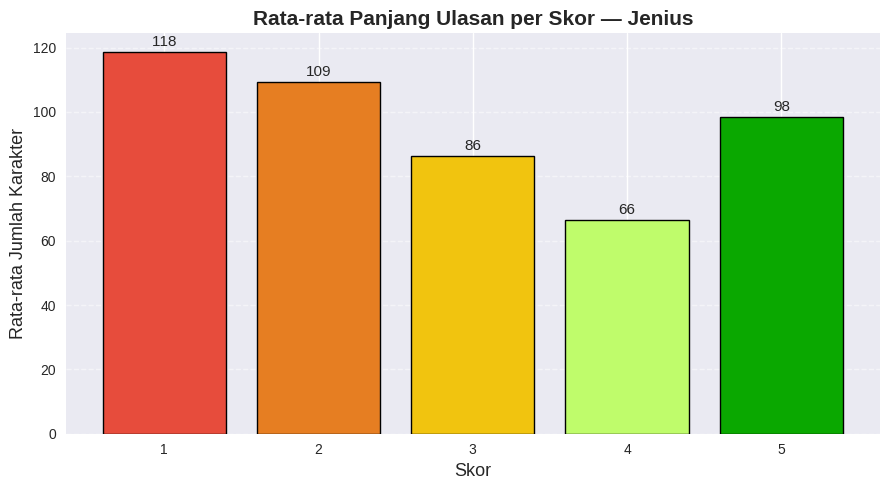

In [13]:
# Visualisasi rata-rata panjang ulasan per skor
avg_len = df_jenius.groupby('score')['text_length'].mean()

plt.figure(figsize=(9, 5))
bars = plt.bar(avg_len.index, avg_len.values,
               color=[score_colors[s] for s in avg_len.index],
               edgecolor='black', linewidth=1)

plt.title('Rata-rata Panjang Ulasan per Skor — Jenius', fontsize=15, fontweight='bold')
plt.xlabel('Skor', fontsize=13)
plt.ylabel('Rata-rata Jumlah Karakter', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{height:.0f}", ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

##Analisis Frekuensi Kata

Kata kunci dominan yang paling sering muncul dalam korpus ulasan diidentifikasi menggunakan ekspresi reguler dengan filter panjang minimal tiga karakter untuk menyaring partikel kata yang tidak bermakna. Hasil 20 kata teratas divisualisasikan dalam diagram batang horizontal.

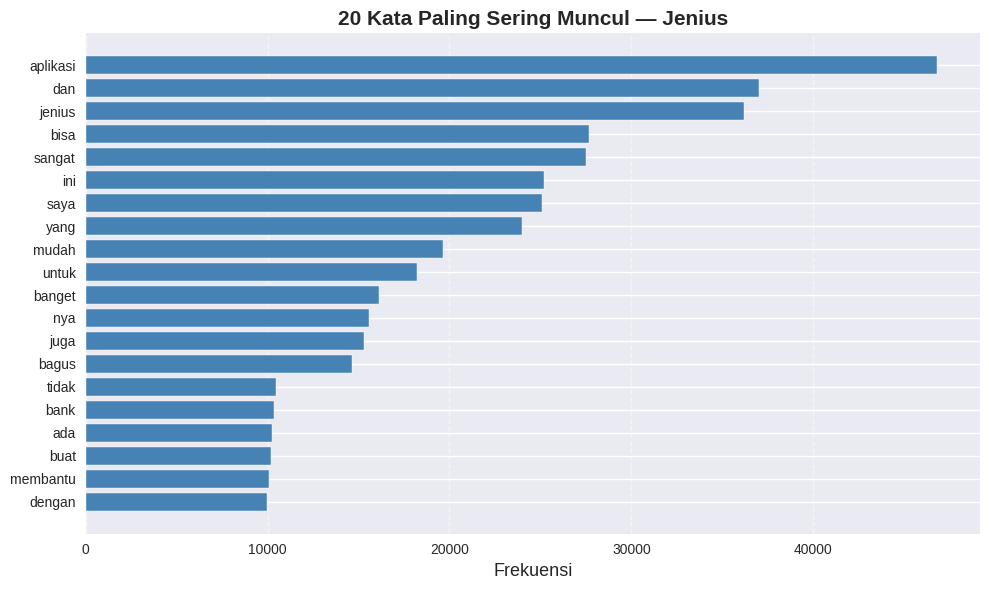

In [14]:
all_text = " ".join(df_jenius['content'].dropna()).lower()
words = re.findall(r'\b[a-zA-Z]{3,}\b', all_text)

word_counts = Counter(words).most_common(20)
labels, values = zip(*word_counts)

plt.figure(figsize=(10, 6))
plt.barh(labels, values, color='steelblue', edgecolor='white')
plt.title('20 Kata Paling Sering Muncul — Jenius', fontsize=15, fontweight='bold')
plt.xlabel('Frekuensi', fontsize=13)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##Analisis Responsivitas Pengembang

Tingkat interaksi pengembang terhadap umpan balik pengguna diukur dengan mengidentifikasi keberadaan konten balasan pada atribut `replyContent`. Hasil dikategorikan dan divisualisasikan dalam diagram lingkaran untuk menunjukkan proporsi responsivitas secara keseluruhan.

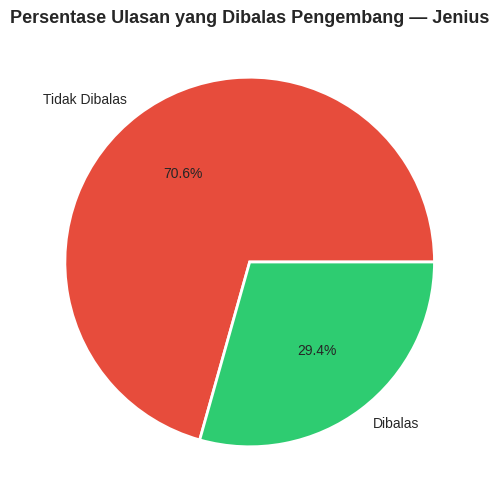

Dibalas     : 29,697 (29.4%)
Tidak dibalas: 71,454 (70.6%)


In [15]:
df_jenius['is_replied'] = df_jenius['replyContent'].notnull()
reply_counts = df_jenius['is_replied'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    reply_counts,
    labels=["Tidak Dibalas", "Dibalas"],
    autopct="%1.1f%%",
    colors=['#e74c3c', '#2ecc71'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Persentase Ulasan yang Dibalas Pengembang — Jenius', fontsize=13, fontweight='bold')
plt.show()

total = reply_counts.sum()
print(f'Dibalas     : {reply_counts[True]:,} ({reply_counts[True]/total*100:.1f}%)')
print(f'Tidak dibalas: {reply_counts[False]:,} ({reply_counts[False]/total*100:.1f}%)')

##Analisis Kecepatan Respons Pengembang

response_category
<1 hari       4265
1–3 hari      4917
3–7 hari      3554
7–14 hari     1112
14–30 hari    2871
>30 hari      1361
Name: count, dtype: int64


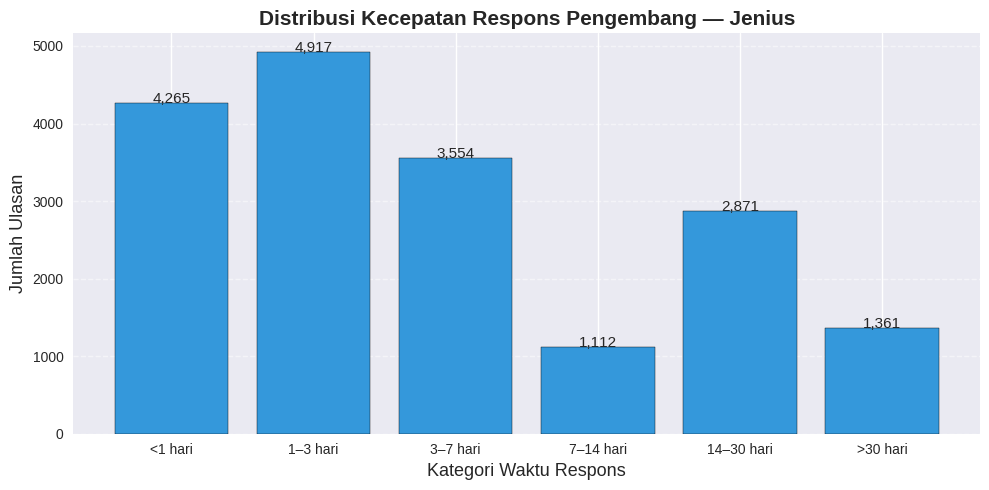

In [16]:
df_reply = df_jenius[df_jenius['replyContent'].notna()].copy()
df_reply['at'] = pd.to_datetime(df_reply['at'])
df_reply['repliedAt'] = pd.to_datetime(df_reply['repliedAt'])
df_reply['response_days'] = (df_reply['repliedAt'] - df_reply['at']).dt.days

df_reply['response_category'] = pd.cut(
    df_reply['response_days'],
    bins=[0, 1, 3, 7, 14, 30, 365],
    labels=["<1 hari", "1–3 hari", "3–7 hari", "7–14 hari", "14–30 hari", ">30 hari"]
)

resp_counts = df_reply['response_category'].value_counts().sort_index()
print(resp_counts)

# Visualisasi
plt.figure(figsize=(10, 5))
plt.bar(resp_counts.index, resp_counts.values, color='#3498db', edgecolor='black')
plt.title('Distribusi Kecepatan Respons Pengembang — Jenius', fontsize=15, fontweight='bold')
plt.xlabel('Kategori Waktu Respons', fontsize=13)
plt.ylabel('Jumlah Ulasan', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(resp_counts.values):
    plt.text(i, v + 5, f"{v:,}", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

##Distribusi Ulasan per Bulan

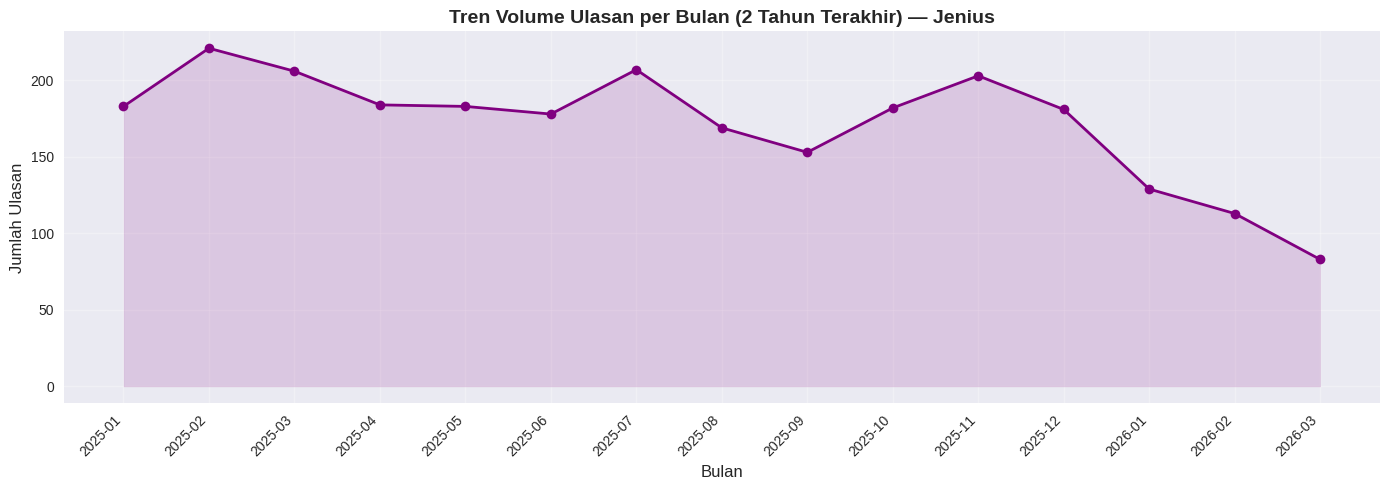

In [17]:
# Ambil data 2 tahun terakhir agar visualisasi lebih fokus
df_recent = df_jenius[df_jenius['at'].dt.year >= df_jenius['at'].dt.year.max() - 1]
df_monthly = df_recent.groupby(df_recent['at'].dt.to_period('M')).size()

plt.figure(figsize=(14, 5))
plt.plot(df_monthly.index.astype(str), df_monthly.values,
         marker='o', linewidth=2, color='purple')
plt.fill_between(df_monthly.index.astype(str), df_monthly.values, alpha=0.15, color='purple')

plt.title('Tren Volume Ulasan per Bulan (2 Tahun Terakhir) — Jenius',
          fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##Analisis Versi Aplikasi

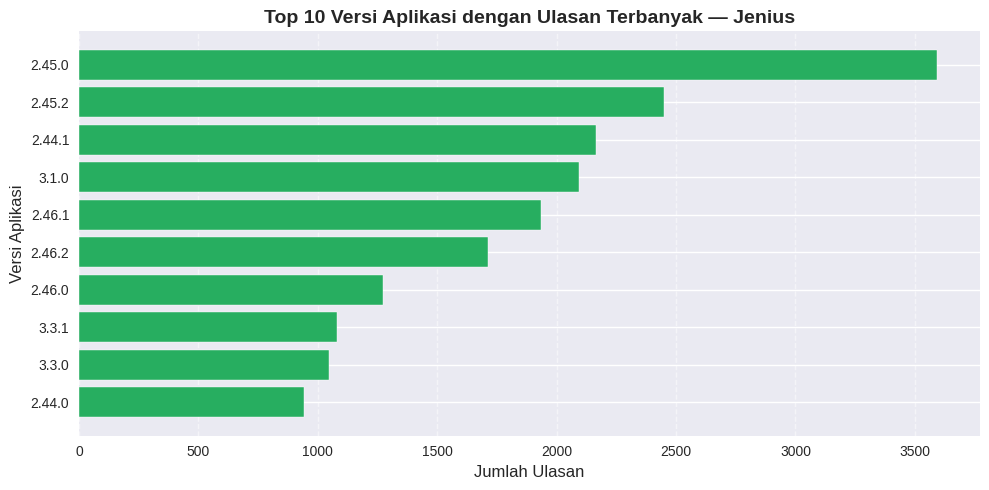

In [18]:
# Top 10 versi dengan ulasan terbanyak
top_versions = df_jenius['reviewCreatedVersion'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_versions.index.astype(str), top_versions.values,
         color='#27ae60', edgecolor='white')
plt.title('Top 10 Versi Aplikasi dengan Ulasan Terbanyak — Jenius',
          fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Ulasan', fontsize=12)
plt.ylabel('Versi Aplikasi', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

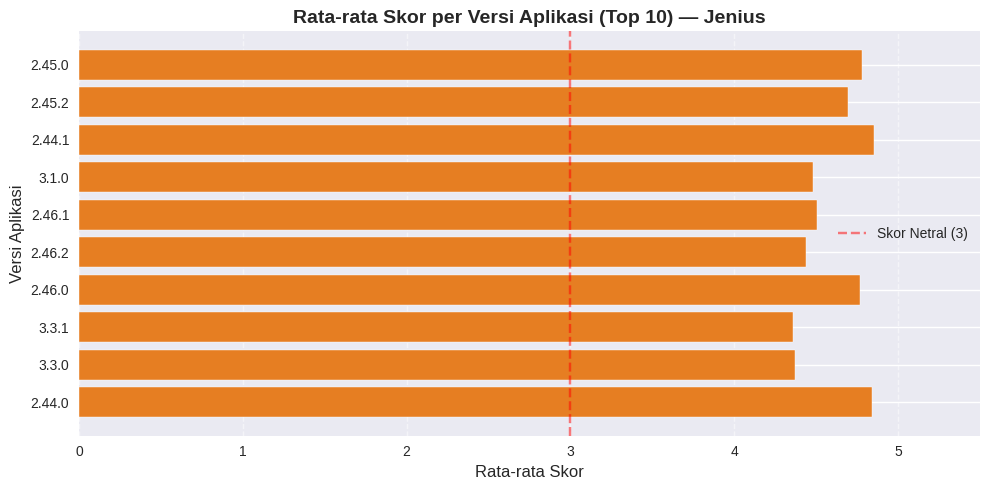

In [19]:
# Rata-rata skor per versi (top 10 versi terbanyak)
top_ver_list = top_versions.index.tolist()
avg_score_ver = (
    df_jenius[df_jenius['reviewCreatedVersion'].isin(top_ver_list)]
    .groupby('reviewCreatedVersion')['score']
    .mean()
    .reindex(top_ver_list)
)

plt.figure(figsize=(10, 5))
bars = plt.barh(avg_score_ver.index.astype(str), avg_score_ver.values,
                color='#e67e22', edgecolor='white')
plt.title('Rata-rata Skor per Versi Aplikasi (Top 10) — Jenius',
          fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Skor', fontsize=12)
plt.ylabel('Versi Aplikasi', fontsize=12)
plt.xlim(0, 5.5)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='Skor Netral (3)')
plt.legend()
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()